In [72]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray

In [2]:
cluster = LocalCluster(n_workers=6, memory_limit='32GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 66,Total memory: 192.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33537,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37283,Total threads: 11
Dashboard: http://127.0.0.1:40791/status,Memory: 32.00 GiB
Nanny: tcp://127.0.0.1:40859,


In [9]:
run_id = 'jbhpd4aq'
ds_attr= xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc')
ds_cycs = xr.open_dataset('/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/cyclones_centers.nc')[['lon','lat']].reindex(time_of_event=ds_attr.time_of_event).isel(timestep_past=slice(-8*7,None))

In [10]:
def lonlat_to_nps_xy_cartopy(
    lon_da: xr.DataArray,
    lat_da: xr.DataArray,
    central_longitude: float = 0.0,
    true_scale_latitude: float | None = 70.0,  # set None for Cartopy's default
) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Project lon/lat (EPSG:4326) to meters in a North Polar Stereographic projection using Cartopy.
    Works with NumPy and dask-backed xarray DataArrays of any dimensionality (e.g., time,y,x).

    Parameters
    ----------
    lon_da, lat_da : xr.DataArray
        Longitudes and latitudes in degrees, same shape.
    central_longitude : float
        Meridian of origin for the projection (deg).
    true_scale_latitude : float | None
        Latitude of true scale (deg). Use ~70 for EPSG:3413-like scale. None -> Cartopy default.

    Returns
    -------
    x_m, y_m : xr.DataArray
        Projected coordinates (meters), same shape/dims as inputs.
    """
    if lon_da.shape != lat_da.shape:
        raise ValueError("lon_da and lat_da must have the same shape")

    geodetic = ccrs.PlateCarree()
    proj = ccrs.NorthPolarStereo(
        central_longitude=central_longitude,
        true_scale_latitude=true_scale_latitude
    )

    def _chunk_transform(lon_chunk: np.ndarray, lat_chunk: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        # Flatten -> transform -> reshape back (fast per-chunk)
        shp = lon_chunk.shape
        lon_f = lon_chunk.ravel()
        lat_f = lat_chunk.ravel()

        # Transform (returns Nx3; columns are x,y,z). z is ignored.
        pts = proj.transform_points(geodetic, lon_f, lat_f)
        x = pts[:, 0].reshape(shp)
        y = pts[:, 1].reshape(shp)
        return x, y

    x_m, y_m = xr.apply_ufunc(
        _chunk_transform,
        lon_da, lat_da,
        input_core_dims=[[], []],          # treat the whole chunk as core
        output_core_dims=[[], []],
        vectorize=False,                    # we handle array chunks, not elementwise
        dask="parallelized",               # works with dask chunks
        output_dtypes=[np.float64, np.float64]
    )

    # Carry over coords/attrs sensibly
    x_m = x_m.assign_coords(lon=lon_da.coords.get("lon", None)).rename("x_m")
    y_m = y_m.assign_coords(lat=lat_da.coords.get("lat", None)).rename("y_m")
    x_m.attrs.update(units="m", crs="NorthPolarStereo")
    y_m.attrs.update(units="m", crs="NorthPolarStereo")
    return x_m, y_m

In [11]:
x,y = lonlat_to_nps_xy_cartopy(ds_cycs.lon,ds_cycs.lat, 0, 90)
ds_cycs['x_nps'] = x.drop('lon')
ds_cycs['y_nps'] = y.drop('lat')# ds_cycs

/tmp/ipykernel_376467/2325811948.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['x_nps'] = x.drop('lon')
/tmp/ipykernel_376467/2325811948.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['y_nps'] = y.drop('lat')# ds_cycs


In [82]:
dist

<xarray.DataArray 'distance_to_cyclone' (time_of_event: 234, timestep_past: 7,
                                         y: 100, x: 100)> Size: 131MB
array([[[[           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         ...,
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan]],

        [[           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
...
          10391.89527324, 10465.83985925, 10541.17150175],
         [12030.19052513, 11938.57163204, 11847.93978868, ...,
          10513.49195445, 10586.58725302, 10661.06572232],
         [12138.26519843, 12047.4682224 , 11957.66177781, ...,
          10635.58718938, 10707.84905816, 10781.48988416]],

        [[ 9857.91077334,  9735.45101178,  9613.52089876, ...,
           7116.44914292,  7214.68423522,  7314.34651247],
         [ 9787.76940223,  9664.42090655,  9541.58315622, ...,
           7014.26064572,  7113.90698676,  7214.9614626 ],
         [ 9719.18880399,  9594.95870733,  9471.22010427, ...,
           6913.46747217,  7014.5457942 ,  7117.01123995],
         ...,
         [12162.77924232, 12057.96299866, 11953.90817   , ...,
           9420.00470442,  9491.83023474,  9565.21666556],
         [12258.22015772, 12154.22701017, 12051.0034053 , ...,
           9542.9162822 ,  9613.8235756 ,  9686.28578954],
         [12354.54977136, 12251.37432424, 12148.9761582 , ...,
           9666.34314449,  9736.35159393,  9807.90859535]]]],
      shape=(234, 7, 100, 100))
Coordinates:
  * y              (y) float64 800B -9e+06 -8.858e+06 ... 4.89e+06 5.031e+06
  * x              (x) float64 800B -9e+06 -8.858e+06 ... 4.89e+06 5.031e+06
    lat            (y, x) float64 80kB -0.06494 0.3892 0.8432 ... 32.39 31.7
    lon            (y, x) float64 80kB -45.0 -44.55 -44.08 ... 136.7 135.8 135.0
  * timestep_past  (timestep_past) timedelta64[ns] 56B -6 days +10:30:00 ... ...
  * time_of_event  (time_of_event) datetime64[ns] 2kB 1999-11-18 ... 2012-05-08

In [84]:
distances_to_cyclone = np.hypot(ds_attr.stack(space=['y','x']).space.x - ds_cycs.chunk(time_of_event=5).x_nps,ds_attr.stack(space=['y','x']).space.y- ds_cycs.y_nps.chunk(time_of_event=5))
dist = distances_to_cyclone.min('track_number').coarsen(timestep_past=8).min().reindex(time_of_event=ds_attr.time_of_event).load().unstack('space')/1000
dist = dist.rename('distance_to_cyclone').assign_coords(timestep_past = ds_attr.timestep_past)
ds_attr['distance_to_cyclone'] = dist

In [93]:

attributions_per_distance = flox.xarray.xarray_reduce(
    # variable qu'on veut aggréger 
    ds_attr.attributions,
    # Variables selon lesquelles on veut grouer : ici il y a deux variables mais on peut en rajouter autant qu'on veut
    ds_attr.distance_to_cyclone,
    ds_attr.timestep_past,
    ds_attr.time_of_event,
    ds_attr.var_name,
    # Fonction à appliquer à chacun des groupes pour aggrégation
    func="mean",
    # Groupes attendus pour chacune des variables : soit on met les bins, soit on met None quand on veut grouper pour toutes les valeurs possibles
    expected_groups=(ds_attr.distance_to_cyclone.quantile(np.arange(0,1.0001,.1)),
                    # np.arange(0,10001,500),
                    # np.arange(0,1.,.02), 
                     None,
                     None,
                     None,),
    # Déterminer si les groupes donnés correspondent à des bins ou non
    isbin=[True, False,False,False],
    # Méthode de calcul parallèl : flox propose plein de méthodes différentes pour optimiser les calculs en fonction de la forme des données
    method="map-reduce",
)
attributions_per_distance['distance_to_cyclone_bins'] = [k.left for k in attributions_per_distance.distance_to_cyclone_bins.values]
attributions_per_distance = attributions_per_distance.rename(distance_to_cyclone_bins='Distance_to_cyclone')

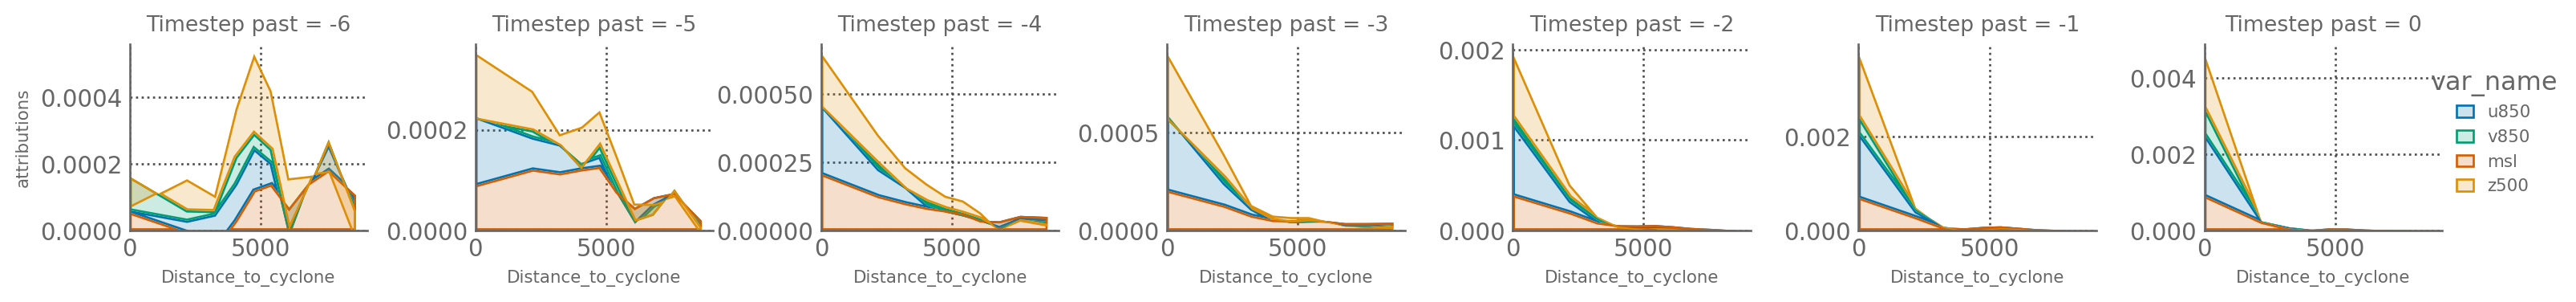

In [94]:
df_ = attributions_per_distance.where(ds_attr.predictions>0.7).mean('time_of_event').to_series().reset_index()

# sns.catplot(df__, x='dist_to_cyclone_bins', y='attributions', kind='bar', hue='var_name', multiple)#
(so.Plot(df_,x='Distance_to_cyclone', y='attributions', color='var_name' )
    .add(so.Area(), so.Stack())
    .facet(col='timestep_past')
    .share(y=False)
    .layout(size=(16,2))
    .theme(plt.style.library["robin"])
    .theme({'axes.grid':True, 'grid.color':'.3'})
    # .share(y=False)
    .limit(x=[0,None], y=[0,None])
    .label(col='Timestep past =')
    .scale(color=so.Nominal(['C0','C2','C3','C1'],order=['u850','v850','msl','z500',]))
    # .scale(x='log')
    )

# axs = f.axes

# , hue='var_name', multiple='stack')
# df__


In [76]:
attributions_per_distance.distance_to_cyclone_bins

<xarray.DataArray 'distance_to_cyclone_bins' (distance_to_cyclone_bins: 20)> Size: 160B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan], dtype=object)
Coordinates:
  * distance_to_cyclone_bins  (distance_to_cyclone_bins) object 160B nan ... nan

In [32]:
ds_attr.attributions#.isel(var_name=0).sel(time_of_event='2011-06-22').plot(col='timestep_past')

<xarray.DataArray 'attributions' (time_of_event: 234, timestep_past: 7,
                                  var_name: 4, y: 100, x: 100)> Size: 262MB
array([[[[[ 0.000000e+00, ...,  1.093627e-05],
          ...,
          [ 5.198075e-05, ..., -4.781005e-05]],

         ...,

         [[ 0.000000e+00, ...,  2.111432e-06],
          ...,
          [ 3.398427e-05, ...,  5.136602e-06]]],


        ...,


        [[[ 0.000000e+00, ..., -6.581366e-05],
          ...,
          [-4.630348e-06, ..., -3.706222e-05]],

         ...,

         [[ 0.000000e+00, ..., -1.484718e-04],
          ...,
          [-2.902590e-05, ...,  4.983727e-06]]]],



       ...,



       [[[[ 0.000000e+00, ..., -9.465110e-07],
          ...,
          [-6.070119e-06, ..., -2.678968e-07]],

         ...,

         [[ 0.000000e+00, ..., -4.048111e-05],
          ...,
          [-6.095633e-06, ...,  2.424525e-06]]],


        ...,


        [[[ 0.000000e+00, ..., -1.539815e-06],
          ...,
          [ 5.021498e-07, ...,  2.028032e-05]],

         ...,

         [[ 0.000000e+00, ...,  9.739583e-05],
          ...,
          [ 7.119255e-06, ..., -8.437233e-06]]]]],
      shape=(234, 7, 4, 100, 100), dtype=float32)
Coordinates:
  * x              (x) float64 800B -9e+06 -8.858e+06 ... 4.89e+06 5.031e+06
  * y              (y) float64 800B -9e+06 -8.858e+06 ... 4.89e+06 5.031e+06
  * time_of_event  (time_of_event) datetime64[ns] 2kB 1999-11-18 ... 2012-05-08
    lat            (y, x) float64 80kB -0.06494 0.3892 0.8432 ... 32.39 31.7
    lon            (y, x) float64 80kB -45.0 -44.55 -44.08 ... 136.7 135.8 135.0
  * var_name       (var_name) <U4 64B 'u850' 'v850' 'msl' 'z500'
  * timestep_past  (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0

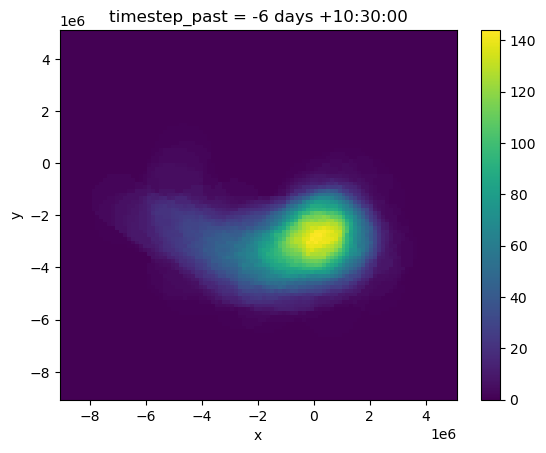

In [64]:
dist.where(dist<1000).bfill('timestep_past').isel(timestep_past=0).count('time_of_event').plot()

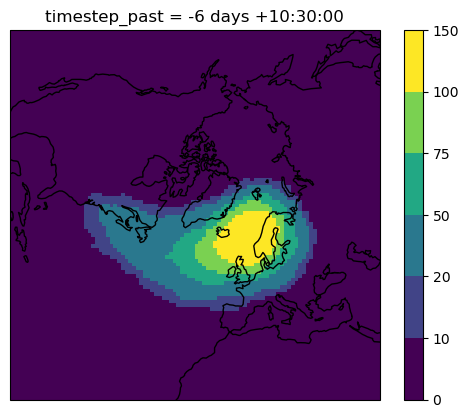

In [71]:
plot= dist.where(dist<1000).bfill('timestep_past').isel(timestep_past=0).count('time_of_event').plot( subplot_kws=dict(projection=ccrs.NorthPolarStereo(0,90)), transform = ccrs.NorthPolarStereo(0,90),levels=[0,10,20,50,75,100,150])
plot.axes.coastlines()

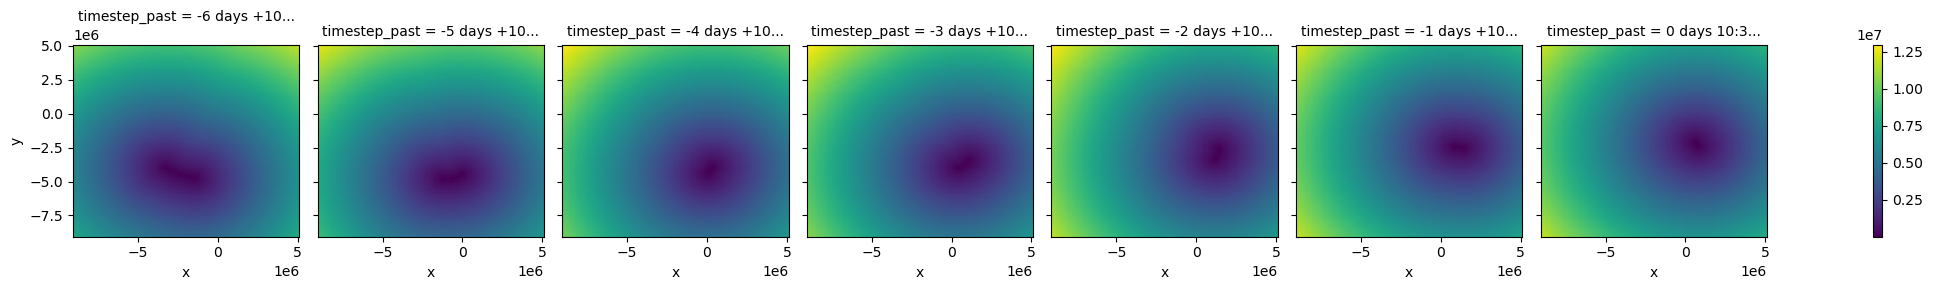

In [36]:
dist.sel(time_of_event='2011-06-22').plot(col='timestep_past')

In [ ]:
dist = distances_to_cyclone.min('track_number').isel(timestep_past=slice(-8*7,None)).coarsen(timestep_past=8).min().reindex(time_of_event=ds_attr.time_of_event).load()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 100.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)


/tmp/ipykernel_373832/1355120910.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['x_nps'] = x.drop('lon')
/tmp/ipykernel_373832/1355120910.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_cycs['y_nps'] = y.drop('lat')


In [44]:
df = ds_cycs.sel(time_of_event='2008-07-23', track_number=0).to_dataframe()

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


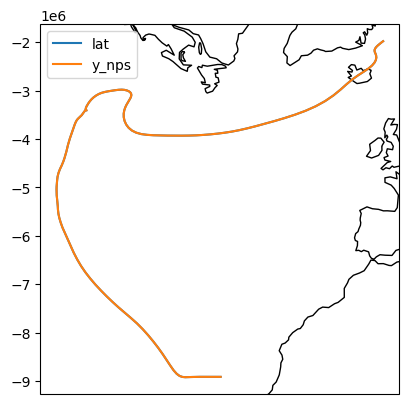

In [46]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.NorthPolarStereo(0,90)))
df.plot(x='lon', y='lat', transform=ccrs.PlateCarree(), ax=ax)
df.plot(x='x_nps', y='y_nps', transform=ccrs.NorthPolarStereo(0,90), ax=ax)
ax.coastlines()

In [9]:
geodetic = ccrs.PlateCarree()  # input CRS (lon/lat in degrees)
north_polar_stereo = ccrs.NorthPolarStereo(0,90)  # output CRS (meters)

# Transform points
x, y = north_polar_stereo.transform_points(geodetic, ds_cycs.lon, ds_cycs.lat)[:, :2].T



ValueError: x and y arrays must be 1 or 2 dimensional